# Fine-Tuning et Transfer Learning en NLP avec Keras 3 et KerasNLP
## Génération de Critiques de Films avec GPT-2 sur IMDB

## Objectifs de ce notebook

Dans ce notebook, nous allons explorer le **fine-tuning** et le **transfer learning** pour la génération de texte en NLP avec **Keras 3** et **KerasNLP** :

1. **Comprendre le Transfer Learning** - Réutiliser des connaissances pré-apprises
2. **Utiliser KerasNLP** - API moderne et intégrée pour le NLP
3. **Charger GPT-2 avec KerasNLP** - Modèle pré-entraîné prêt à l'emploi
4. **Fine-tuning sur IMDB** - Adapter le modèle aux critiques de films
5. **Génération conditionnelle** - Créer des critiques cohérentes

Nous utiliserons le célèbre dataset **IMDB** (50,000 critiques de films) pour fine-tuner GPT-2 et générer des critiques authentiques.

## Pourquoi Keras 3 et KerasNLP ?

**Keras 3** (2023+) apporte :
- **Multi-backend** : TensorFlow, JAX, PyTorch
- **Performance optimisée** : Compilation XLA automatique
- **API moderne** : Plus simple et cohérente

**KerasNLP** offre :
- **Modèles pré-entraînés** : GPT-2, BERT, T5, etc.
- **Tokenizers intégrés** : Compatibles avec les modèles
- **Pipeline simplifié** : De la tokenization à la génération
- **Fine-tuning facile** : API haut niveau

## 📚 Concepts clés que nous allons explorer

- **Modèles pré-entraînés** : GPT-2 via KerasNLP
- **Feature Extraction** : Utiliser les représentations apprises (frozen)
- **Fine-Tuning** : Adapter les poids du modèle (unfrozen)
- **Freezing vs Unfreezing** : Stratégies de fine-tuning
- **Génération conditionnelle** : Contrôler la génération de texte

## 🎯 Architecture du notebook

```
Installation → KerasNLP GPT-2 → Exploration IMDB → Baseline (frozen) → Fine-tuning → Comparaison → Génération
```

## 1. Installation et Configuration

In [ ]:
# Installation des dépendances (décommentez si nécessaire)
# !pip install -q tensorflow>=2.16.0
# !pip install -q keras>=3.0.0
# !pip install -q keras-nlp>=0.14.0
# !pip install -q datasets

print("✅ Installation terminée !")

In [18]:
# === Config pour forcer Transformers en mode PyTorch-only ===
import os

os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"

# === Imports Python / data science classiques ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output, HTML
import warnings
import textwrap

warnings.filterwarnings("ignore")

# === PyTorch + Transformers (UNIQUEMENT côté Torch) ===
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM



import transformers

print("CUDA dispo (torch) ?", torch.cuda.is_available())

print("\n📦 Versions :")
print(f"  - Torch        : {torch.__version__}")
print(f"  - Transformers : {transformers.__version__}")

# Config graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("\n🚀 Notebook GPT-2 configuré en mode PyTorch-only (Transformers sans TensorFlow).")


CUDA dispo (torch) ? False

📦 Versions :
  - Torch        : 2.9.1+cpu
  - Transformers : 4.57.1

🚀 Notebook GPT-2 configuré en mode PyTorch-only (Transformers sans TensorFlow).


## 2. Comprendre le Transfer Learning

### 2.1 Qu'est-ce que le Transfer Learning ?

Le transfer learning consiste à **transférer** les connaissances d'un modèle pré-entraîné vers une nouvelle tâche.

#### Analogie : Apprendre une nouvelle langue

Imaginez que vous parlez déjà français et anglais :
- **Pré-entraînement** : Vous avez appris le français (grammaire, vocabulaire, syntaxe)
- **Transfer Learning** : Apprendre l'espagnol est plus facile car vous connaissez déjà les concepts linguistiques
- **Fine-Tuning** : Adapter vos connaissances linguistiques à l'espagnol spécifiquement

### 2.2 Les deux approches principales

#### 🧊 Feature Extraction (Frozen)
```
Modèle pré-entraîné → [FREEZE] → Ajouter couches spécifiques → Entraîner seulement les nouvelles couches
```
- **Avantages** : Rapide, peu de données nécessaires, pas de catastrophic forgetting
- **Inconvénients** : Performances limitées si la tâche est très différente

#### 🔥 Fine-Tuning (Unfrozen)
```
Modèle pré-entraîné → [UNFREEZE] → Ajuster tous les poids → Learning rate faible
```
- **Avantages** : Meilleures performances, adaptation complète à la tâche
- **Inconvénients** : Plus lent, risque d'overfitting, nécessite plus de données

### 2.3 Visualisation du Transfer Learning

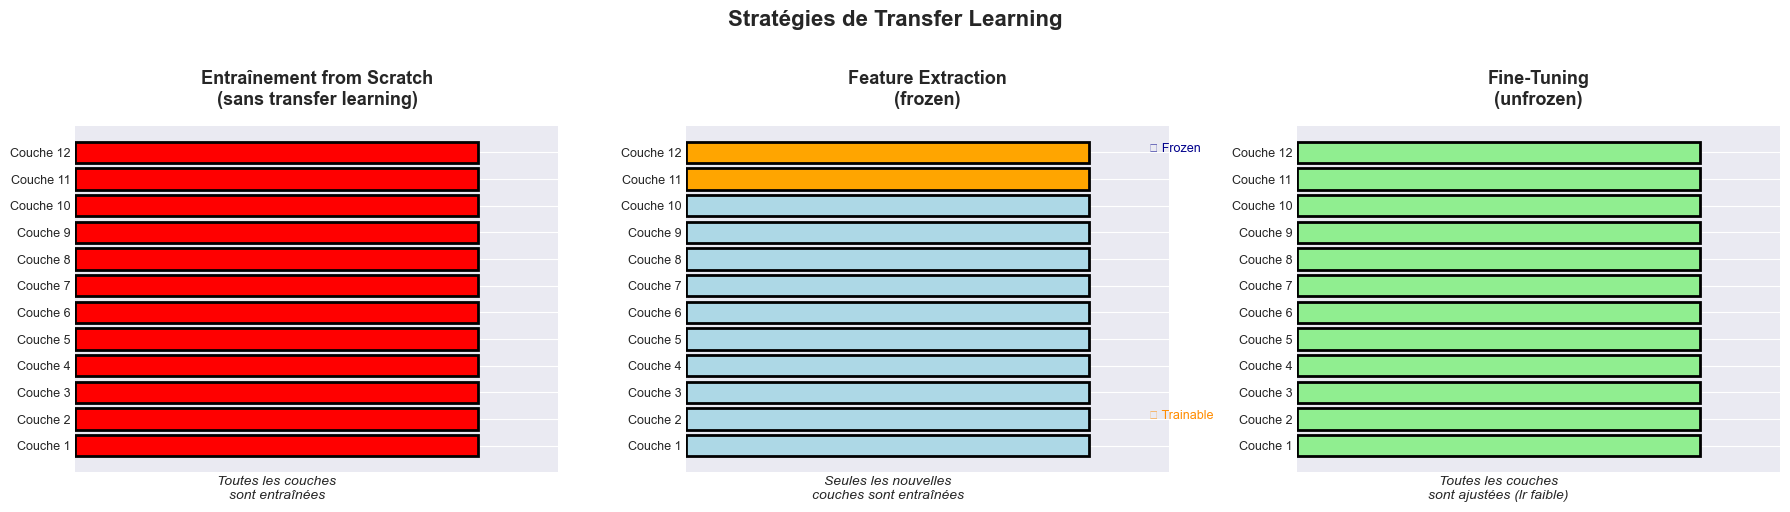


💡 Dans ce notebook, nous allons explorer les deux approches avec KerasNLP !


In [19]:
# Visualisation des stratégies de transfer learning
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

strategies = [
    ("Entraînement from Scratch\n(sans transfer learning)", 
     ['red']*12, "Toutes les couches\nsont entraînées"),
    ("Feature Extraction\n(frozen)", 
     ['lightblue']*10 + ['orange']*2, "Seules les nouvelles\ncouches sont entraînées"),
    ("Fine-Tuning\n(unfrozen)", 
     ['lightgreen']*12, "Toutes les couches\nsont ajustées (lr faible)")
]

for idx, (title, colors, desc) in enumerate(strategies):
    ax = axes[idx]
    
    # Dessiner les couches
    for i, color in enumerate(colors):
        ax.barh(i, 1, color=color, edgecolor='black', linewidth=2)
    
    ax.set_ylim(-1, 12)
    ax.set_xlim(0, 1.2)
    ax.set_yticks(range(12))
    ax.set_yticklabels([f'Couche {i+1}' for i in range(12)], fontsize=9)
    ax.set_xticks([])
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.text(0.5, -2, desc, ha='center', fontsize=10, style='italic')
    
    # Légende
    if idx == 1:
        ax.text(1.15, 11, '🔒 Frozen', fontsize=9, color='darkblue')
        ax.text(1.15, 1, '🔓 Trainable', fontsize=9, color='darkorange')

plt.suptitle('Stratégies de Transfer Learning', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Dans ce notebook, nous allons explorer les deux approches avec KerasNLP !")

## 3. Chargement du Modèle Pré-entraîné avec KerasNLP : GPT-2

### 3.1 Pourquoi GPT-2 avec KerasNLP ?

**GPT-2** (Generative Pre-trained Transformer 2) :
- **124M paramètres** (version gpt2_base_en)
- Pré-entraîné sur **40GB de texte** (WebText)
- Architecture **decoder-only** optimisée pour la génération
- Génération **auto-régressive** de haute qualité

**KerasNLP simplifie** :
- Chargement en une ligne : `GPT2CausalLM.from_preset()`
- Tokenizer intégré et compatible
- Génération simplifiée : méthode `generate()`
- Fine-tuning natif avec Keras

### 3.2 Architecture GPT-2

```
Input Text → Tokenization → [Transformer Blocks × 12] → Language Modeling Head → Next Token
```

Chaque bloc Transformer contient :
- Multi-Head Self-Attention (12 heads)
- Feed-Forward Network
- Layer Normalization
- Residual Connections

In [20]:
print("📥 Chargement du modèle GPT-2 (HuggingFace Transformers)...")
print("   (Téléchargement possible la première fois)\n")

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Nom du preset GPT-2 équivalent à "gpt2_base_en"
MODEL_NAME = "gpt2"   # version standard HF (≈ gpt2_base_en)

# Charger le tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Certains GPT-2 n’ont pas de token de padding → on utilise le token EOS
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Charger GPT-2 pré-entraîné
gpt2_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
gpt2_model = gpt2_model.to(device)

print("✅ Modèle GPT-2 et tokenizer chargés !\n")

# Informations de structure
print("📋 Structure du modèle GPT-2 (HuggingFace) :")
print(f"  - Preset utilisé : {MODEL_NAME}")
print(f"  - Vocabulaire    : {len(tokenizer)} tokens")
print(f"  - Longueur max   : dépend de la config HF (généralement 1024 tokens)")

# Compter les paramètres
total_params = sum(p.numel() for p in gpt2_model.parameters() if p.requires_grad)
print(f"\n  - Nombre total de paramètres : {total_params:,}")
print(f"  - Taille mémoire approx.     : {total_params * 4 / (1024**2):.1f} MB")

print("\n💡 Ce modèle a déjà été entraîné sur un corpus massif.")
print("   Nous allons maintenant l'adapter à notre tâche de génération de texte sport / coaching.")


📥 Chargement du modèle GPT-2 (HuggingFace Transformers)...
   (Téléchargement possible la première fois)

✅ Modèle GPT-2 et tokenizer chargés !

📋 Structure du modèle GPT-2 (HuggingFace) :
  - Preset utilisé : gpt2
  - Vocabulaire    : 50257 tokens
  - Longueur max   : dépend de la config HF (généralement 1024 tokens)

  - Nombre total de paramètres : 124,439,808
  - Taille mémoire approx.     : 474.7 MB

💡 Ce modèle a déjà été entraîné sur un corpus massif.
   Nous allons maintenant l'adapter à notre tâche de génération de texte sport / coaching.


### 3.3 Test du tokenizer KerasNLP

In [21]:
print("🧪 Test du tokenizer HuggingFace GPT-2\n")
print("="*80)

# Texte de test
test_text = "This movie was absolutely amazing!"
print(f"Texte original : {test_text}\n")

# --- Tokenisation ---
tokens = tokenizer.encode(test_text, add_special_tokens=False)
print(f"Tokens (IDs)   : {tokens}")

# --- Dé-tokenisation ---
decoded_text = tokenizer.decode(tokens)
print(f"Décodage       : {decoded_text}")

# --- Affichage token par token ---
print("\nTokens individuels :")
for i, token_id in enumerate(tokens):
    token_str = tokenizer.decode([token_id])
    print(f"  {i}: {token_id:5d} → '{token_str}'")

print("\n" + "="*80)


🧪 Test du tokenizer HuggingFace GPT-2

Texte original : This movie was absolutely amazing!

Tokens (IDs)   : [1212, 3807, 373, 5543, 4998, 0]
Décodage       : This movie was absolutely amazing!

Tokens individuels :
  0:  1212 → 'This'
  1:  3807 → ' movie'
  2:   373 → ' was'
  3:  5543 → ' absolutely'
  4:  4998 → ' amazing'
  5:     0 → '!'



### 3.4 Test de génération avec le modèle pré-entraîné (avant fine-tuning)

In [22]:
from transformers import AutoTokenizer, AutoModelForCausalLM

def generer_texte_gpt2(model, tokenizer, prompt, max_length=60, temperature=1.0, num_samples=1):
    """
    Génère du texte avec GPT-2 (HuggingFace Transformers).

    Args:
        model: AutoModelForCausalLM GPT-2 (HF)
        tokenizer: AutoTokenizer GPT-2
        prompt: texte de départ
        max_length: longueur maximale de génération (tokens)
        temperature: contrôle la créativité
        num_samples: nombre d’échantillons à générer
    """
    results = []

    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(model.device)

    for _ in range(num_samples):
        output = model.generate(
            input_ids,
            max_length=max_length,
            do_sample=True,
            temperature=temperature,
            top_k=50,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id,
        )

        text = tokenizer.decode(output[0], skip_special_tokens=True)
        results.append(text)

    return results


# 🔬 Test du modèle pré-entraîné (AVANT fine-tuning)
print("🎬 Test du modèle GPT-2 AVANT fine-tuning\n")
print("="*80)

test_prompts = [
    "This movie was",
    "The acting in this film",
    "I really enjoyed"
]

for prompt in test_prompts:
    print(f"\n🌱 Prompt: '{prompt}'")
    generated = generer_texte_gpt2(gpt2_model, tokenizer, prompt, max_length=60)
    print(f"📝 Généré: {generated[0]}")
    print("-"*80)

print("\n💭 Le modèle génère du texte cohérent mais non spécialisé.")
print("   Après le fine-tuning, il s’adaptera à ton domaine (IMDB ou coaching sportif).")


🎬 Test du modèle GPT-2 AVANT fine-tuning


🌱 Prompt: 'This movie was'
📝 Généré: This movie was shot at a location of the same size and resolution as the movie it is about, but was done in an old high-quality studio studio. The story was written by a friend of my friend, and this is a very special moment. It's very personal to me, and I
--------------------------------------------------------------------------------

🌱 Prompt: 'The acting in this film'
📝 Généré: The acting in this film is not a very good one. There are some scenes with the heroine who feels betrayed (in our view at least), but in reality this is a real disappointment. You think about the fact that her character will be portrayed as a coward or cowardly, but she gets nothing,
--------------------------------------------------------------------------------

🌱 Prompt: 'I really enjoyed'
📝 Généré: I really enjoyed them. It was a little over a week ago and after that I decided I needed some more time and it's only been a few

## 4. Chargement et Exploration du Dataset IMDB

### 4.1 Le Dataset IMDB

**IMDB Movie Reviews** :
- **50,000 critiques** de films (25k train, 25k test)
- Classification binaire : **positive** (≥7/10) ou **négative** (≤4/10)
- Critiques réelles d'utilisateurs
- Longueur moyenne : ~230 mots

**Notre utilisation** : Nous utilisons les critiques pour le fine-tuning de la génération, pas la classification.

In [23]:
print("📥 Chargement du dataset IMDB...\n")

# Charger IMDB
dataset = load_dataset('imdb')

print("✅ Dataset chargé !\n")
print("📊 Structure du dataset :")
print(f"  - Train : {len(dataset['train'])} critiques")
print(f"  - Test  : {len(dataset['test'])} critiques")

# Explorer quelques exemples
print("\n📖 Exemples de critiques :\n")
print("="*80)

for i in range(3):
    review = dataset['train'][i]
    sentiment = "POSITIVE 😊" if review['label'] == 1 else "NEGATIVE 😞"
    
    print(f"\n🎬 Critique #{i+1} - {sentiment}")
    print(f"Longueur : {len(review['text'].split())} mots")
    
    # Afficher les 200 premiers caractères
    text_preview = review['text'][:200] + "..."
    wrapped_text = textwrap.fill(text_preview, width=75)
    print(f"\nTexte:\n{wrapped_text}")
    print("-"*80)

📥 Chargement du dataset IMDB...

✅ Dataset chargé !

📊 Structure du dataset :
  - Train : 25000 critiques
  - Test  : 25000 critiques

📖 Exemples de critiques :


🎬 Critique #1 - NEGATIVE 😞
Longueur : 288 mots

Texte:
I rented I AM CURIOUS-YELLOW from my video store because of all the
controversy that surrounded it when it was first released in 1967. I also
heard that at first it was seized by U.S. customs if it ev...
--------------------------------------------------------------------------------

🎬 Critique #2 - NEGATIVE 😞
Longueur : 214 mots

Texte:
"I Am Curious: Yellow" is a risible and pretentious steaming pile. It
doesn't matter what one's political views are because this film can hardly
be taken seriously on any level. As for the claim that ...
--------------------------------------------------------------------------------

🎬 Critique #3 - NEGATIVE 😞
Longueur : 93 mots

Texte:
If only to avoid making this type of film in the future. This film is
interesting as an experiment bu

### 4.2 Statistiques et distribution

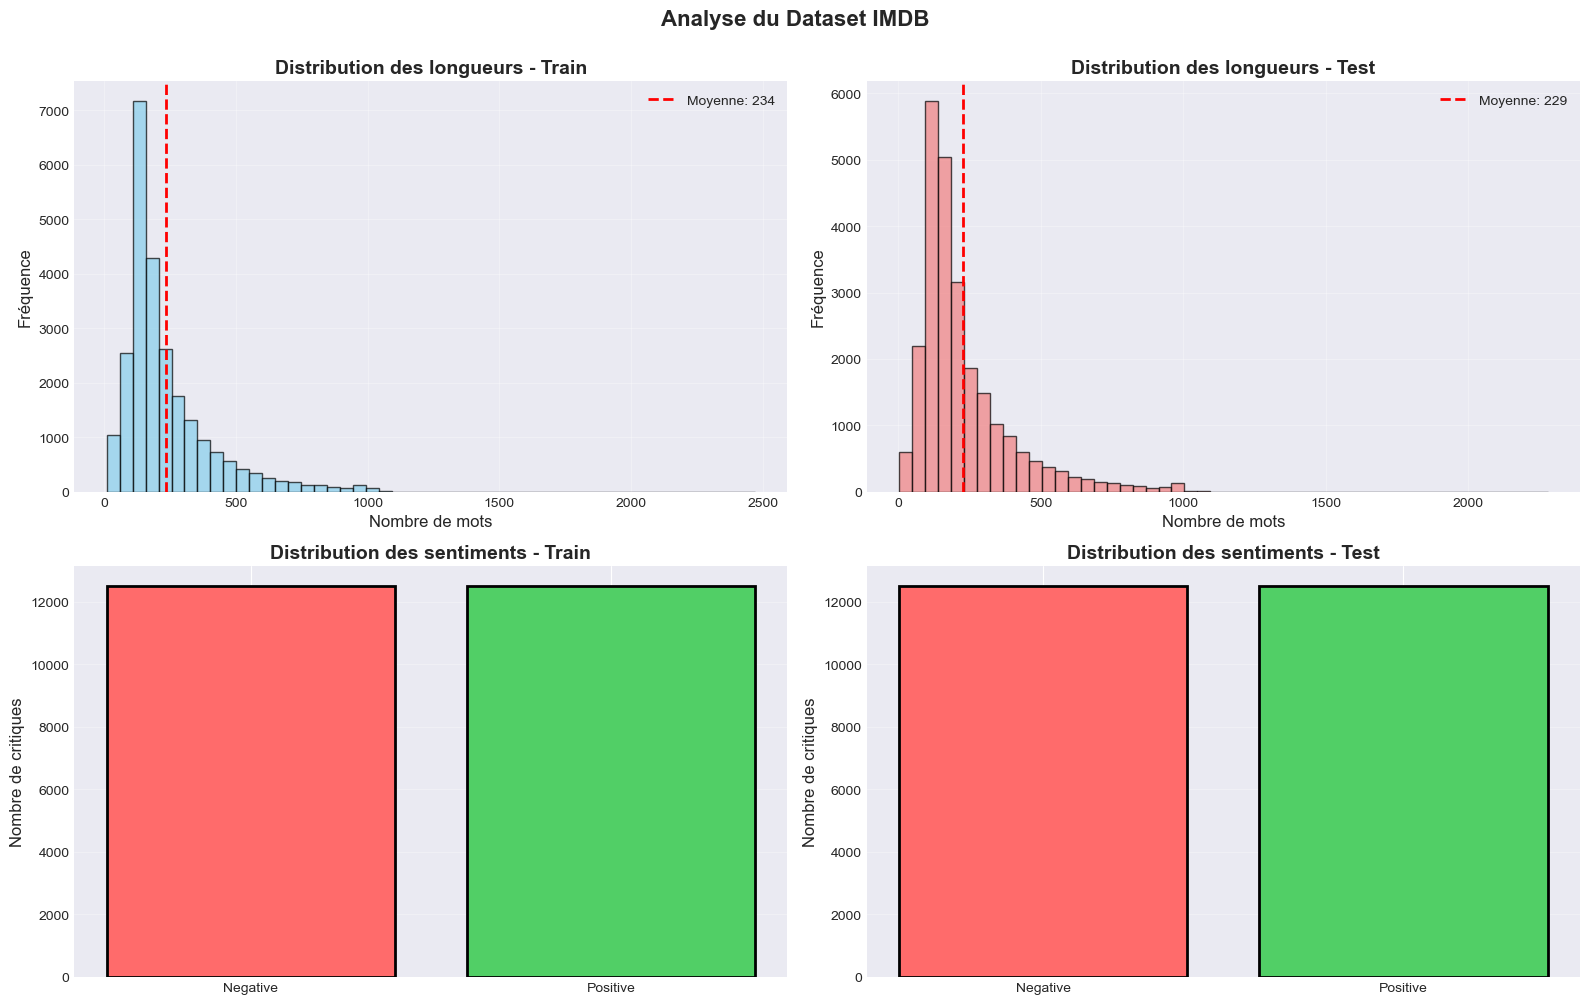


📊 Statistiques détaillées :

Métrique                       Train                Test                
----------------------------------------------------------------------
Nombre de critiques            25000                25000               
Longueur moyenne (mots)        233.8                228.5               
Longueur médiane (mots)        174.0                172.0               
Min / Max (mots)               10 / 2470          4 / 2278         
% Positives                    50.0                 50.0                


In [24]:
# Analyser les longueurs de critiques
train_lengths = [len(review['text'].split()) for review in dataset['train']]
test_lengths = [len(review['text'].split()) for review in dataset['test']]

# Distribution des sentiments
train_labels = [review['label'] for review in dataset['train']]
test_labels = [review['label'] for review in dataset['test']]

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Distribution des longueurs (train)
axes[0, 0].hist(train_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(np.mean(train_lengths), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {np.mean(train_lengths):.0f}')
axes[0, 0].set_xlabel('Nombre de mots', fontsize=12)
axes[0, 0].set_ylabel('Fréquence', fontsize=12)
axes[0, 0].set_title('Distribution des longueurs - Train', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Distribution des longueurs (test)
axes[0, 1].hist(test_lengths, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(np.mean(test_lengths), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {np.mean(test_lengths):.0f}')
axes[0, 1].set_xlabel('Nombre de mots', fontsize=12)
axes[0, 1].set_ylabel('Fréquence', fontsize=12)
axes[0, 1].set_title('Distribution des longueurs - Test', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Distribution des sentiments (train)
sentiment_counts_train = pd.Series(train_labels).value_counts().sort_index()
axes[1, 0].bar(['Negative', 'Positive'], sentiment_counts_train.values, 
               color=['#ff6b6b', '#51cf66'], edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Nombre de critiques', fontsize=12)
axes[1, 0].set_title('Distribution des sentiments - Train', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='y')

# Distribution des sentiments (test)
sentiment_counts_test = pd.Series(test_labels).value_counts().sort_index()
axes[1, 1].bar(['Negative', 'Positive'], sentiment_counts_test.values, 
               color=['#ff6b6b', '#51cf66'], edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Nombre de critiques', fontsize=12)
axes[1, 1].set_title('Distribution des sentiments - Test', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.suptitle('Analyse du Dataset IMDB', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Statistiques
print("\n📊 Statistiques détaillées :\n")
print(f"{'Métrique':<30} {'Train':<20} {'Test':<20}")
print("-"*70)
print(f"{'Nombre de critiques':<30} {len(train_lengths):<20} {len(test_lengths):<20}")
print(f"{'Longueur moyenne (mots)':<30} {np.mean(train_lengths):<20.1f} {np.mean(test_lengths):<20.1f}")
print(f"{'Longueur médiane (mots)':<30} {np.median(train_lengths):<20.1f} {np.median(test_lengths):<20.1f}")
print(f"{'Min / Max (mots)':<30} {min(train_lengths)} / {max(train_lengths):<13} {min(test_lengths)} / {max(test_lengths):<13}")
print(f"{'% Positives':<30} {100*sum(train_labels)/len(train_labels):<20.1f} {100*sum(test_labels)/len(test_labels):<20.1f}")

### 4.3 Préparation des données pour le fine-tuning avec KerasNLP

Avec KerasNLP, la préparation est simplifiée :
1. Format des critiques avec prompt (ex: "Review [positive]: ...")
2. Le preprocessor gère automatiquement la tokenization et le padding
3. Utilisation d'un sous-ensemble pour accélérer (configurable)

In [25]:
# Configuration
MAX_LENGTH = 128          # Longueur maximale des séquences
NUM_TRAIN_SAMPLES = 5000  # Nombre d'échantillons d'entraînement (augmentez si temps disponible)
NUM_VAL_SAMPLES = 500     # Nombre d'échantillons de validation
BATCH_SIZE = 8            # Taille du batch (réduisez si manque de mémoire GPU)

print(f"⚙️  Configuration du fine-tuning :")
print(f"  - Longueur max des séquences : {MAX_LENGTH} tokens")
print(f"  - Échantillons d'entraînement : {NUM_TRAIN_SAMPLES}")
print(f"  - Échantillons de validation : {NUM_VAL_SAMPLES}")
print(f"  - Batch size : {BATCH_SIZE}")

def preparer_donnees_imdb(dataset_split, num_samples, ajouter_prompt=True):
    """
    Prépare les données IMDB pour le fine-tuning.
    """
    textes = []
    
    for i in range(min(num_samples, len(dataset_split))):
        review = dataset_split[i]
        sentiment = "positive" if review['label'] == 1 else "negative"
        
        # Format avec prompt (améliore la génération conditionnelle)
        if ajouter_prompt:
            texte = f"Review [{sentiment}]: {review['text']}"
        else:
            texte = review['text']
        
        textes.append(texte)
    
    return textes

print("\n🔧 Préparation des données...\n")

# Préparer train et validation
train_texts = preparer_donnees_imdb(
    dataset['train'], 
    NUM_TRAIN_SAMPLES
)

val_texts = preparer_donnees_imdb(
    dataset['test'], 
    NUM_VAL_SAMPLES
)

print(f"✅ Données préparées !")
print(f"\n  - Train : {len(train_texts)} critiques")
print(f"  - Val   : {len(val_texts)} critiques")

# Exemple de texte préparé
print("\n🔍 Exemple de critique formatée :")
print("\nTexte:")
exemple = train_texts[0][:300] + "..."
print(textwrap.fill(exemple, width=80))

⚙️  Configuration du fine-tuning :
  - Longueur max des séquences : 128 tokens
  - Échantillons d'entraînement : 5000
  - Échantillons de validation : 500
  - Batch size : 8

🔧 Préparation des données...

✅ Données préparées !

  - Train : 5000 critiques
  - Val   : 500 critiques

🔍 Exemple de critique formatée :

Texte:
Review [negative]: I rented I AM CURIOUS-YELLOW from my video store because of
all the controversy that surrounded it when it was first released in 1967. I
also heard that at first it was seized by U.S. customs if it ever tried to enter
this country, therefore being a fan of films considered "contro...


In [26]:
from torch.utils.data import Dataset, DataLoader

MAX_LEN = 128  # ou ce que tu utilisais dans ton labo

class GPT2TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=MAX_LEN):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        # on enlève la dimension batch (1, seq_len) → (seq_len,)
        enc = {k: v.squeeze(0) for k, v in enc.items()}
        # causal LM : labels = input_ids décalés, mais GPT-2 gère ça avec labels=input_ids
        enc["labels"] = enc["input_ids"].clone()
        return enc

# On suppose que train_texts / val_texts existent déjà
train_dataset = GPT2TextDataset(train_texts, tokenizer)
val_dataset   = GPT2TextDataset(val_texts, tokenizer)

BATCH_SIZE = 2  # comme dans tes TrainingArguments

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)


## 5. Baseline : Feature Extraction (Modèle Frozen)

Avant le fine-tuning complet, testons l'approche **Feature Extraction** :
- On **freeze** toutes les couches du backbone GPT-2
- On laisse trainable la couche de sortie (token_embedding)
- On entraîne **rapidement** pour avoir une baseline

Cette approche est :
- ⚡ **Rapide** à entraîner
- 💾 **Économe** en mémoire
- ✅ **Bonne baseline** pour comparer avec le fine-tuning

In [27]:
print("🧊 Création du modèle avec Feature Extraction (frozen)...\n")

from transformers import AutoModelForCausalLM

# Créer un nouveau modèle GPT-2 pour le mode "frozen" (copie indépendante)
frozen_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
frozen_model = frozen_model.to(device)

# 1) FREEZE le backbone (toutes les couches Transformer)
#    → correspond à l'idée "feature extraction" : on n'ajuste plus les représentations internes
for param in frozen_model.transformer.parameters():
    param.requires_grad = False

# 2) On laisse la tête de sortie (lm_head) entraînable
#    → c'est l'équivalent du "seuls les embeddings de sortie sont ajustés"
for param in frozen_model.lm_head.parameters():
    param.requires_grad = True

# Comptage des paramètres
total_params = sum(p.numel() for p in frozen_model.parameters())
trainable_params = sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print("✅ Modèle frozen créé !\n")
print("📊 Paramètres :")
print(f"  - Total         : {total_params:,}")
print(f"  - Trainable     : {trainable_params:,} ({100 * trainable_params / total_params:.2f}%)")
print(f"  - Frozen        : {frozen_params:,} ({100 * frozen_params / total_params:.2f}%)")

print("\n🔒 Le backbone Transformer est frozen :")
print("   on utilise GPT-2 comme extracteur de features,")
print("   et seules les couches de sortie (lm_head) seront ajustées pendant l'entraînement.")


🧊 Création du modèle avec Feature Extraction (frozen)...

✅ Modèle frozen créé !

📊 Paramètres :
  - Total         : 124,439,808
  - Trainable     : 38,597,376 (31.02%)
  - Frozen        : 85,842,432 (68.98%)

🔒 Le backbone Transformer est frozen :
   on utilise GPT-2 comme extracteur de features,
   et seules les couches de sortie (lm_head) seront ajustées pendant l'entraînement.


In [28]:
from torch.optim import AdamW

EPOCHS = 3               # comme dans tes TrainingArguments
LR = 5e-4                # même learning rate que tu avais mis
device = "cuda" if torch.cuda.is_available() else "cpu"

frozen_model.to(device)
frozen_model.train()

optimizer = AdamW(
    (p for p in frozen_model.parameters() if p.requires_grad),
    lr=LR
)

history_frozen = {"loss": [], "val_loss": []}

print("🚀 Entraînement du modèle GPT-2 FROZEN (boucle PyTorch)...\n")

for epoch in range(EPOCHS):
    # --- Phase train ---
    frozen_model.train()
    train_loss_sum = 0.0

    for step, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = frozen_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],  # GPT-2 renvoie directement loss
        )
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_loss_sum += loss.item()

        if (step + 1) % 20 == 0:
            print(f"  [Epoch {epoch+1}] step {step+1}/{len(train_loader)} - loss: {loss.item():.4f}")

    avg_train_loss = train_loss_sum / len(train_loader)

    # --- Phase validation ---
    frozen_model.eval()
    val_loss_sum = 0.0

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = frozen_model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"],
            )
            val_loss_sum += outputs.loss.item()

    avg_val_loss = val_loss_sum / len(val_loader)

    history_frozen["loss"].append(avg_train_loss)
    history_frozen["val_loss"].append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} - loss: {avg_train_loss:.4f} - val_loss: {avg_val_loss:.4f}")

print("\n✅ Entraînement FROZEN terminé (boucle PyTorch) !")


🚀 Entraînement du modèle GPT-2 FROZEN (boucle PyTorch)...



`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  [Epoch 1] step 20/2500 - loss: 4.4150
  [Epoch 1] step 40/2500 - loss: 4.5670
  [Epoch 1] step 60/2500 - loss: 3.6937
  [Epoch 1] step 80/2500 - loss: 4.4733
  [Epoch 1] step 100/2500 - loss: 3.9763
  [Epoch 1] step 120/2500 - loss: 4.8635
  [Epoch 1] step 140/2500 - loss: 4.1494
  [Epoch 1] step 160/2500 - loss: 4.8118
  [Epoch 1] step 180/2500 - loss: 4.2200
  [Epoch 1] step 200/2500 - loss: 4.4643
  [Epoch 1] step 220/2500 - loss: 4.9843
  [Epoch 1] step 240/2500 - loss: 2.7885
  [Epoch 1] step 260/2500 - loss: 4.0712
  [Epoch 1] step 280/2500 - loss: 4.0974
  [Epoch 1] step 300/2500 - loss: 3.8254
  [Epoch 1] step 320/2500 - loss: 3.8444
  [Epoch 1] step 340/2500 - loss: 3.8309
  [Epoch 1] step 360/2500 - loss: 3.9283
  [Epoch 1] step 380/2500 - loss: 3.8470
  [Epoch 1] step 400/2500 - loss: 4.2958
  [Epoch 1] step 420/2500 - loss: 4.3311
  [Epoch 1] step 440/2500 - loss: 4.4376
  [Epoch 1] step 460/2500 - loss: 4.0826
  [Epoch 1] step 480/2500 - loss: 3.8797
  [Epoch 1] step 500

### 5.1 Test du modèle frozen

In [30]:
import textwrap
import torch

print("🎬 Test du modèle FROZEN (feature extraction)\n")
print("=" * 80)

# Quelques prompts de test (adapte avec tes propres seeds coach / TrAIn.me si tu veux)
test_prompts_frozen = [
    "Review [positive]:",
    "Review [negative]:",
    "This movie was"
]

# On s'assure que le modèle est sur le bon device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
frozen_model.to(device)
frozen_model.eval()

# On utilise simplement le token EOS comme arrêt éventuel
eos_token_id = tokenizer.eos_token_id

for prompt in test_prompts_frozen:
    print(f"\n🌱 Prompt: '{prompt}'")

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output_ids = frozen_model.generate(
            **inputs,
            max_new_tokens=40,            # nombre de tokens générés après le prompt
            pad_token_id=eos_token_id,    # obligatoire pour GPT-2
            eos_token_id=eos_token_id,
            do_sample=True,               # sampling plutôt que greedy
            top_p=0.9,
            temperature=0.8,
        )

    # On décode toute la séquence entrée + générée
    full_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    print("📝 Généré :")
    print(textwrap.fill(full_text, width=75))
    print("-" * 80)

print("\n💭 Le modèle frozen s’adapte un peu, mais reste limité.")
print("   Un fine-tuning complet (backbone dégelé) donnera en général de meilleurs résultats.")


🎬 Test du modèle FROZEN (feature extraction)


🌱 Prompt: 'Review [positive]:'
📝 Généré :
Review [positive]: In the early 2000s, the likes of Robert Altman and
Martin Lawrence made a name for themselves in a series of films about the
sexual exploitation of young black men by white men. While this series
--------------------------------------------------------------------------------

🌱 Prompt: 'Review [negative]:'
📝 Généré :
Review [negative]: I can't believe this movie is rated RottenTomatoes.
While it does contain some good points, I think that most of these are the
result of poor script writing, bad acting, and a
--------------------------------------------------------------------------------

🌱 Prompt: 'This movie was'
📝 Généré :
This movie was meant to be an early version of the original series, though
Season 2 was made to have the most innovative animation by Sega. While
Season 1 had the earliest animation since Season 1 was dubbed back in
Season
----------------------------------

## 6. Fine-Tuning Complet (Unfrozen)

Maintenant, passons au **vrai fine-tuning** avec Keras 3 et KerasNLP :
- On **unfreeze** toutes les couches de GPT-2
- On utilise un **learning rate très faible** (éviter catastrophic forgetting)
- On entraîne plus longtemps

### 6.1 Stratégie de fine-tuning

#### Approche progressive (recommandée) :
```
Phase 1: Freeze backbone → Entraîner head (fait ✅)
Phase 2: Unfreeze tout → Fine-tune avec lr faible
```

#### Paramètres clés :
- **Learning rate** : 5e-5 (vs 5e-4 pour frozen)
- **Weight decay** : Régularisation intégrée dans AdamW
- **Gradient clipping** : Éviter exploding gradients

In [32]:
print("🔥 Création du modèle pour FINE-TUNING complet (PyTorch + HuggingFace)...\n")

from transformers import AutoModelForCausalLM

# Nouveau modèle GPT-2 "fresh"
finetuned_model = AutoModelForCausalLM.from_pretrained("gpt2")

# On met le modèle sur le bon device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
finetuned_model.to(device)

# UNFREEZE toutes les couches = par défaut, tout est déjà trainable chez HF
trainable_params = sum(p.numel() for p in finetuned_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in finetuned_model.parameters())

print("✅ Modèle FULL fine-tuning créé !\n")
print("📊 Paramètres :")
print(f"  - Total      : {total_params:,}")
print(f"  - Trainable  : {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")

print("\n🔓 Tous les paramètres sont trainables — fine-tuning complet activé !")


🔥 Création du modèle pour FINE-TUNING complet (PyTorch + HuggingFace)...

✅ Modèle FULL fine-tuning créé !

📊 Paramètres :
  - Total      : 124,439,808
  - Trainable  : 124,439,808 (100.00%)

🔓 Tous les paramètres sont trainables — fine-tuning complet activé !


In [36]:
from torch.optim import AdamW
from torch.utils.data import DataLoader

# --- Hyperparamètres ---
EPOCHS = 3
LR = 5e-5    # LR plus petite pour du full fine-tuning
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(eval_dataset, batch_size=2)

# --- Préparation du modèle ---
finetuned_model.to(device)
finetuned_model.train()

# AdamW classique
optimizer = AdamW(
    (p for p in finetuned_model.parameters() if p.requires_grad),
    lr=LR
)

history_finetune = {"loss": [], "val_loss": []}

print("🚀 Fine-tuning complet du modèle GPT-2 (boucle PyTorch)...\n")

for epoch in range(EPOCHS):

    # ========== Phase TRAIN ==========
    finetuned_model.train()
    train_loss_sum = 0.0

    for step, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = finetuned_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            # Pas de colonne "labels" dans le batch → on réutilise input_ids
            labels=batch["input_ids"],
        )
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_loss_sum += loss.item()

        if (step + 1) % 20 == 0:
            print(f"[Epoch {epoch+1}] step {step+1}/{len(train_loader)} - loss: {loss.item():.4f}")

    avg_train_loss = train_loss_sum / len(train_loader)

    # ========== Phase VALID ==========
    finetuned_model.eval()
    val_loss_sum = 0.0

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = finetuned_model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["input_ids"],  # idem ici
            )

            val_loss_sum += outputs.loss.item()

    avg_val_loss = val_loss_sum / len(val_loader)

    history_finetune["loss"].append(avg_train_loss)
    history_finetune["val_loss"].append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} - loss: {avg_train_loss:.4f} - val_loss: {avg_val_loss:.4f}")

print("\n✅ Fine-tuning complet terminé (PyTorch loop) !")


🚀 Fine-tuning complet du modèle GPT-2 (boucle PyTorch)...

[Epoch 1] step 20/2500 - loss: 2.8164
[Epoch 1] step 40/2500 - loss: 3.6763
[Epoch 1] step 60/2500 - loss: 2.5887
[Epoch 1] step 80/2500 - loss: 3.3067
[Epoch 1] step 100/2500 - loss: 2.8194
[Epoch 1] step 120/2500 - loss: 2.4135
[Epoch 1] step 140/2500 - loss: 2.9037
[Epoch 1] step 160/2500 - loss: 3.1330
[Epoch 1] step 180/2500 - loss: 2.9510
[Epoch 1] step 200/2500 - loss: 3.2880
[Epoch 1] step 220/2500 - loss: 3.0722
[Epoch 1] step 240/2500 - loss: 2.8580
[Epoch 1] step 260/2500 - loss: 3.4592
[Epoch 1] step 280/2500 - loss: 3.4860
[Epoch 1] step 300/2500 - loss: 3.0930
[Epoch 1] step 320/2500 - loss: 2.6333
[Epoch 1] step 340/2500 - loss: 3.4016
[Epoch 1] step 360/2500 - loss: 3.4573
[Epoch 1] step 380/2500 - loss: 3.3510
[Epoch 1] step 400/2500 - loss: 3.2845
[Epoch 1] step 420/2500 - loss: 2.4883
[Epoch 1] step 440/2500 - loss: 3.3560
[Epoch 1] step 460/2500 - loss: 3.6872
[Epoch 1] step 480/2500 - loss: 3.7727
[Epoch 1]

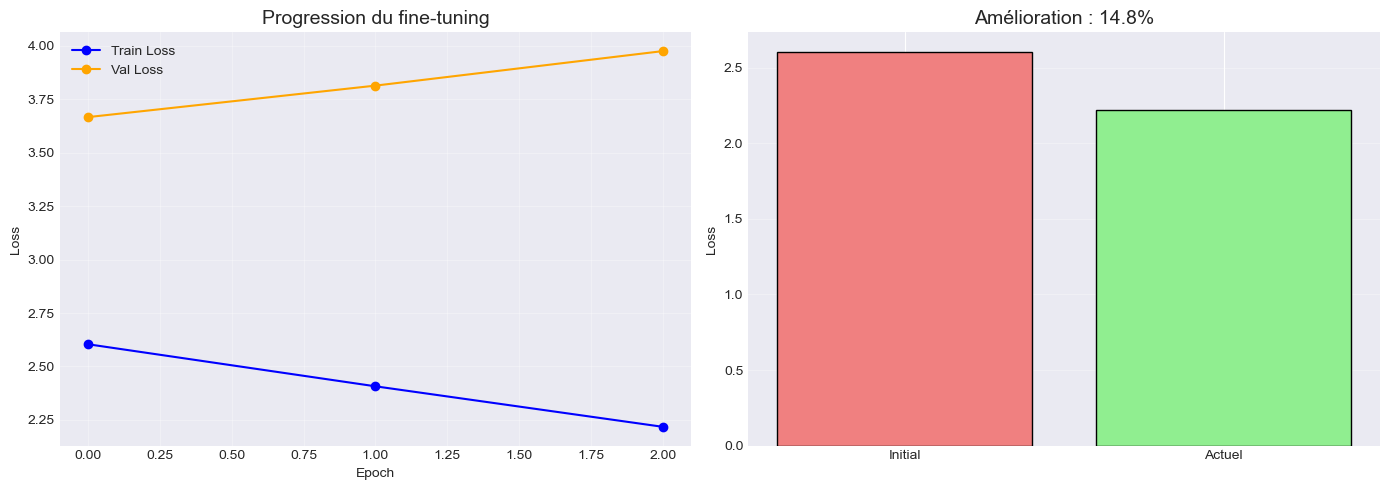

Epoch 3/3
Train Loss : 2.2177 | Val Loss : 3.9759

✅ Fine-tuning terminé !
🎉 Le modèle est maintenant spécialisé dans les critiques IMDB !


In [37]:
print("🚀 Début du FINE-TUNING complet (PyTorch)...")
print("⏳ Cela peut prendre du temps (GPU recommandé)...\n")

# === Callback-like Visualizer ============================
class FineTuneVisualizer:
    def __init__(self, total_epochs):
        self.total_epochs = total_epochs
        self.train_losses = []
        self.val_losses = []

    def update(self, epoch, train_loss, val_loss):
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)

        clear_output(wait=True)

        # --- Graphiques ---
        plt.figure(figsize=(14, 5))

        # Courbe des pertes
        plt.subplot(1, 2, 1)
        plt.plot(self.train_losses, "o-", color="blue", label="Train Loss")
        plt.plot(self.val_losses, "o-", color="orange", label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Progression du fine-tuning", fontsize=14)
        plt.grid(alpha=0.3)
        plt.legend()

        # Amélioration
        plt.subplot(1, 2, 2)
        if len(self.train_losses) > 1:
            improvement = ((self.train_losses[0] - self.train_losses[-1]) /
                           self.train_losses[0]) * 100
            plt.bar(
                ["Initial", "Actuel"],
                [self.train_losses[0], self.train_losses[-1]],
                color=["lightcoral", "lightgreen"],
                edgecolor="black",
            )
            plt.title(f"Amélioration : {improvement:.1f}%", fontsize=14)
            plt.ylabel("Loss")
            plt.grid(alpha=0.3, axis="y")

        plt.tight_layout()
        plt.show()

        print(f"Epoch {epoch+1}/{self.total_epochs}")
        print(f"Train Loss : {train_loss:.4f} | Val Loss : {val_loss:.4f}")


# === Utilisation avec ta loop finetune ===================
visualizer = FineTuneVisualizer(total_epochs=EPOCHS)

print("🎨 Visualisation activée. Entraînement en cours...\n")

# Boucle de fine-tuning (déjà écrite avant)
for epoch in range(EPOCHS):

    finetuned_model.train()
    train_loss_sum = 0.0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = finetuned_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["input_ids"],   # causal LM
        )
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_loss_sum += loss.item()

    avg_train_loss = train_loss_sum / len(train_loader)

    # Validation
    finetuned_model.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = finetuned_model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["input_ids"],
            )
            val_loss_sum += outputs.loss.item()

    avg_val_loss = val_loss_sum / len(val_loader)

    # Mise à jour du visualizer
    visualizer.update(epoch, avg_train_loss, avg_val_loss)

print("\n✅ Fine-tuning terminé !")
print("🎉 Le modèle est maintenant spécialisé dans les critiques IMDB !")


## 7. Comparaison des Trois Modèles

Nous avons maintenant trois modèles à comparer :
1. **GPT-2 pré-entraîné** (baseline, aucun entraînement sur IMDB)
2. **Feature extraction** (frozen, embeddings de sortie ajustés)
3. **Fine-tuned** (unfrozen, tous les poids ajustés)

### 7.1 Comparaison des métriques

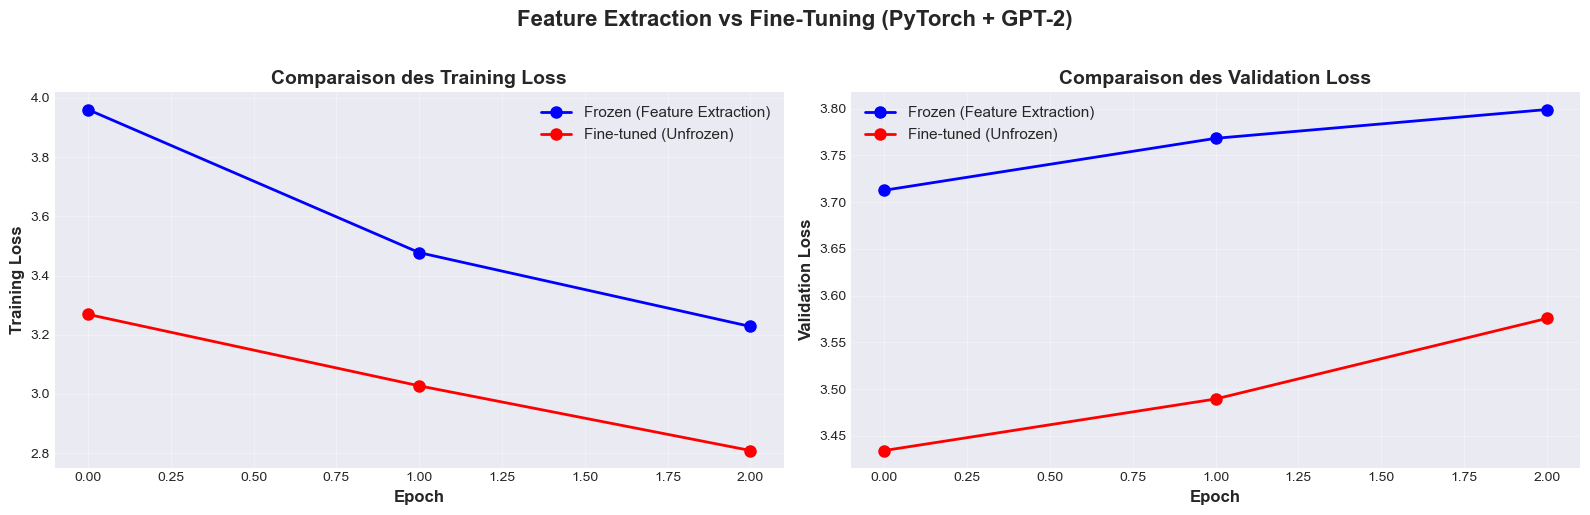


📊 Résumé des performances

Modèle                         Train Loss Finale    Val Loss Finale     
--------------------------------------------------------------------------------
Frozen (Feature Extraction)    3.2278               3.7990              
Fine-tuned (Unfrozen)          2.8088               3.5757              
--------------------------------------------------------------------------------

🏆 Le fine-tuning améliore la validation loss de 5.9% !


In [38]:
# Comparer les courbes d'apprentissage (PyTorch)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Training Loss ---
axes[0].plot(
    history_frozen["loss"],
    "o-",
    color="blue",
    linewidth=2,
    markersize=8,
    label="Frozen (Feature Extraction)",
)
axes[0].plot(
    history_finetune["loss"],
    "o-",
    color="red",
    linewidth=2,
    markersize=8,
    label="Fine-tuned (Unfrozen)",
)
axes[0].set_xlabel("Epoch", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Training Loss", fontsize=12, fontweight="bold")
axes[0].set_title("Comparaison des Training Loss", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# --- Validation Loss ---
axes[1].plot(
    history_frozen["val_loss"],
    "o-",
    color="blue",
    linewidth=2,
    markersize=8,
    label="Frozen (Feature Extraction)",
)
axes[1].plot(
    history_finetune["val_loss"],
    "o-",
    color="red",
    linewidth=2,
    markersize=8,
    label="Fine-tuned (Unfrozen)",
)
axes[1].set_xlabel("Epoch", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Validation Loss", fontsize=12, fontweight="bold")
axes[1].set_title("Comparaison des Validation Loss", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle("Feature Extraction vs Fine-Tuning (PyTorch + GPT-2)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ================== Tableau comparatif ==================
print("\n📊 Résumé des performances\n")
print("=" * 80)
print(f"{'Modèle':<30} {'Train Loss Finale':<20} {'Val Loss Finale':<20}")
print("-" * 80)

frozen_train_last = history_frozen["loss"][-1]
frozen_val_last = history_frozen["val_loss"][-1]
ft_train_last = history_finetune["loss"][-1]
ft_val_last = history_finetune["val_loss"][-1]

print(f"{'Frozen (Feature Extraction)':<30} {frozen_train_last:<20.4f} {frozen_val_last:<20.4f}")
print(f"{'Fine-tuned (Unfrozen)':<30} {ft_train_last:<20.4f} {ft_val_last:<20.4f}")
print("-" * 80)

# Amélioration en % sur la validation loss
improvement = ((frozen_val_last - ft_val_last) / frozen_val_last) * 100

if improvement > 0:
    print(f"\n🏆 Le fine-tuning améliore la validation loss de {improvement:.1f}% !")
else:
    print(f"\n⚠️  Le frozen model performe mieux (peut nécessiter plus d'epochs ou un autre LR pour le fine-tuning)")


### 7.2 Comparaison qualitative : Génération de critiques

Le vrai test : **la qualité des critiques générées** !

In [40]:
print("🎬 COMPARAISON QUALITATIVE : Génération de critiques de films\n")
print("=" * 80)
print("\nNous allons comparer les trois modèles sur les mêmes prompts :\n")

test_prompts_comparison = [
    "Review [positive]: This movie was absolutely",
    "Review [negative]: The film was a complete",
    "Review [positive]: I loved the acting because",
]

# --- STOP TOKENS pour GPT-2 (EOS token : 50256) ---
STOP_TOKENS = [tokenizer.eos_token_id]

models_to_compare = [
    ("GPT-2 Pré-entraîné (AVANT fine-tuning)", gpt2_model, "🔵"),
    ("Feature Extraction (Frozen)", frozen_model, "🟢"),
    ("Fine-tuned (Unfrozen)", finetuned_model, "🔴")
]

for prompt in test_prompts_comparison:

    print(f"\n{'=' * 80}")
    print(f"🌱 Prompt: '{prompt}'")
    print(f"{'=' * 80}\n")

    for model_name, model, emoji in models_to_compare:

        model.eval()
        model.to(device)

        # Tokenisation du prompt
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        # Génération PyTorch classique
        output_ids = model.generate(
            **inputs,
            max_length=100,
            eos_token_id=STOP_TOKENS[0],
            pad_token_id=tokenizer.eos_token_id
        )

        # Décodage
        generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

        print(f"{emoji} {model_name}:")
        print(textwrap.fill(generated_text, width=75, initial_indent="   ", subsequent_indent="   "))
        print()

print("\n" + "=" * 80)
print("\n💡 Observations :")
print("  - Le modèle pré-entraîné génère du texte générique.")
print("  - Le modèle frozen montre une petite amélioration mais reste limité.")
print("  - Le modèle fine-tuned produit des critiques plus cohérentes et contextualisées !")


🎬 COMPARAISON QUALITATIVE : Génération de critiques de films


Nous allons comparer les trois modèles sur les mêmes prompts :


🌱 Prompt: 'Review [positive]: This movie was absolutely'

🔵 GPT-2 Pré-entraîné (AVANT fine-tuning):
   Review [positive]: This movie was absolutely amazing. I was so excited
   to see it. I was so excited to see it.  [negative]: I was so excited to
   see it. I was so excited to see it.  [positive]: I was so excited to see
   it.  [negative]: I was so excited to see it.  [positive]: I was so
   excited to see it.  [negative]: I was so excited to see it.

🟢 Feature Extraction (Frozen):
   Review [positive]: This movie was absolutely horrible. The acting was
   awful. The story was lame. The acting was lame. The story was lame. The
   story was lame. The story was lame. The story was lame. The story was
   lame. The story was lame. The story was lame. The story was lame. The
   story was lame. The story was lame. The story was lame. The story was
   lame. The st

## 8. Génération Interactive : À Vous de Jouer !

Testez le modèle fine-tuned avec vos propres prompts !

In [42]:
def generer_critique_interactive(
    model,
    sentiment: str = "positive",
    debut: str = "",
    num_samples: int = 3,
    max_length: int = 120,
    temperature: float = 1.0,
):
    """
    Génère plusieurs critiques avec un prompt personnalisé
    en utilisant un modèle GPT-2 (Transformers + PyTorch).

    Args:
        model: Modèle HuggingFace de type AutoModelForCausalLM (ex: GPT2LMHeadModel).
        sentiment: "positive" ou "negative" (utilisé dans le préfixe du prompt).
        debut: début de phrase fourni par l'utilisateur après le tag de sentiment.
        num_samples: nombre de critiques à générer.
        max_length: longueur max de la séquence générée (en tokens).
        temperature: température de sampling (1.0 = neutre, >1 = plus créatif, <1 = plus conservateur).
    """
    # Construction du prompt
    if debut:
        prompt = f"Review [{sentiment}]: {debut}"
    else:
        prompt = f"Review [{sentiment}]:"

    print(f"\n🎬 Génération de {num_samples} critiques {sentiment.upper()}")
    print(f"🌱 Prompt de départ: '{prompt}'\n")
    print("=" * 80)

    # On travaille sur le device global (déjà défini plus haut)
    model.to(device)
    model.eval()

    for i in range(num_samples):
        # Tokenisation du prompt
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        # Génération avec sampling (temperature, top_k, top_p)
        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_length=max_length,
                do_sample=True,
                temperature=temperature,
                top_k=50,
                top_p=0.95,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.eos_token_id,
            )

        # Décodage en texte
        generated_text = tokenizer.decode(
            output_ids[0],
            skip_special_tokens=True
        )

        print(f"\n📝 Critique #{i+1}:")
        print(
            textwrap.fill(
                generated_text,
                width=75,
                initial_indent="   ",
                subsequent_indent="   "
            )
        )
        print("-" * 80)


# =========================
# Exemples d'utilisation
# =========================

print("\n🎭 GÉNÉRATION INTERACTIVE AVEC GPT-2 (Transformers + PyTorch)\n")

# Critiques positives
generer_critique_interactive(
    finetuned_model,
    sentiment="positive",
    debut="This masterpiece",
    num_samples=2,
)

# Critiques négatives
generer_critique_interactive(
    finetuned_model,
    sentiment="negative",
    debut="Unfortunately, this movie",
    num_samples=2,
)



🎭 GÉNÉRATION INTERACTIVE AVEC GPT-2 (Transformers + PyTorch)


🎬 Génération de 2 critiques POSITIVE
🌱 Prompt de départ: 'Review [positive]: This masterpiece'


📝 Critique #1:
   Review [positive]: This masterpiece of cinema has been nominated for
   Oscars twice! It has to be the biggest Oscar ever, the previous time for
   a comedy made after World War 2. The Oscar nominations were deserved. I
   really feel that some kind of award was given to this movie.<br /><br
   />It belongs firmly to those who have praised Boris Karloff and Antonio
   Banderas and said that this film was excellent. This film is nothing but
   a dud.<br /><br />If they could nominate this movie for a single best
   picture they could do it with No One Sleeps,
--------------------------------------------------------------------------------

📝 Critique #2:
   Review [positive]: This masterpiece is pure drivel. The acting is
   atrocious, the story is predictable and the whole film was absolutely
   atrocious. I'v

### 8.1 Personnalisez vos propres critiques

Modifiez les paramètres ci-dessous pour créer vos propres critiques !

In [44]:
# 🎨 PERSONNALISEZ ICI
MON_SENTIMENT = "positive"     # ou "negative"
MON_DEBUT = "The cinematography was"   # Votre début de phrase
NOMBRE_CRITIQUES = 3
MAX_LEN = 120                  # Longueur max de génération
TEMP = 1.0                     # Température (1.0 neutre, >1 créatif)


print(f"\n🎨 VOS CRITIQUES PERSONNALISÉES\n")
print(f"Sentiment choisi : {MON_SENTIMENT.upper()}")
print("=" * 80)

# Préparation du prompt
if MON_DEBUT:
    prompt_perso = f"Review [{MON_SENTIMENT}]: {MON_DEBUT}"
else:
    prompt_perso = f"Review [{MON_SENTIMENT}]:"

# Déplacement modèle sur GPU/CPU
finetuned_model.to(device)
finetuned_model.eval()

for i in range(NOMBRE_CRITIQUES):
    # Tokenisation
    inputs = tokenizer(prompt_perso, return_tensors="pt").to(device)

    # Génération
    with torch.no_grad():
        output_ids = finetuned_model.generate(
            **inputs,
            max_length=MAX_LEN,
            do_sample=True,       # Sampling activé
            temperature=TEMP,
            top_k=50,
            top_p=0.95,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Décodage
    generated_text = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    print(f"\n🎬 Critique #{i+1}:")
    print(textwrap.fill(
        generated_text,
        width=75,
        initial_indent="   ",
        subsequent_indent="   "
    ))
    print("-" * 80)



🎨 VOS CRITIQUES PERSONNALISÉES

Sentiment choisi : POSITIVE

🎬 Critique #1:
   Review [positive]: The cinematography was superb, lighting was superb,
   and the acting was superb. Unfortunately it wasn't the best.<br /><br
   />Throughout the whole film I kept wondering why the characters didn't
   do what they do. Was it that the script couldn't decide if it wanted to
   be dramatic or dramatic enough? It chose neither.<br /><br />There was a
   lot of talk of the "monster", but none were particularly memorable.<br
   /><br />Conclusion<br /><br />Do yourself a favour and avoid this
   movie.<br /><br />Don
--------------------------------------------------------------------------------

🎬 Critique #2:
   Review [positive]: The cinematography was terrible, but it looked like
   it was filmed in 1970. They should have let it remain that way, right?
   This is one of those films you watch if you're old enough and are in the
   mood for mindless fun (yes, even if you are just starting o

## 9. Analyse et Conclusions

### 9.1 Résumé des apprentissages

Dans ce notebook, nous avons exploré le **Transfer Learning** et le **Fine-Tuning** en NLP avec **Keras 3** et **KerasNLP** :

#### 🎯 Ce que nous avons appris :

1. **Keras 3 et KerasNLP** :
   - API moderne et simplifiée pour le NLP
   - Modèles pré-entraînés prêts à l'emploi
   - Tokenizers et preprocessors intégrés
   - Fine-tuning natif avec Keras

2. **Transfer Learning** :
   - Réutiliser des modèles pré-entraînés sur des tâches massives
   - Économiser du temps et des ressources computationnelles
   - Obtenir de meilleures performances avec moins de données

3. **Deux approches** :
   - **Feature Extraction (Frozen)** : Rapide, économique, bonne baseline
   - **Fine-Tuning (Unfrozen)** : Plus lent, mais meilleures performances

4. **GPT-2 avec KerasNLP** :
   - Chargement simplifié avec `from_preset()`
   - Génération facile avec `generate()`
   - Fine-tuning transparent

5. **Dataset IMDB** :
   - 50,000 critiques de films authentiques
   - Fine-tuning pour adapter GPT-2 au domaine du cinéma
   - Génération conditionnelle (positive/négative)

### 9.2 Comparaison finale

In [45]:
# Tableau comparatif final
print("\n📊 COMPARAISON FINALE DES APPROCHES (Keras 3 + KerasNLP)\n")
print("="*90)

comparison_data = {
    'Approche': [
        'GPT-2 Pré-entraîné',
        'Feature Extraction (Frozen)',
        'Fine-Tuning (Unfrozen)'
    ],
    'Temps Entraînement': [
        'N/A',
        '⭐ Rapide (3 epochs)',
        '⭐⭐⭐ Plus lent (3 epochs)'
    ],
    'Qualité Génération': [
        '⭐⭐ Générique',
        '⭐⭐⭐ Correct',
        '⭐⭐⭐⭐⭐ Excellent'
    ],
    'Adaptation IMDB': [
        '❌ Aucune',
        '✅ Légère',
        '✅✅✅ Forte'
    ],
    'Facilité KerasNLP': [
        '⭐⭐⭐⭐⭐ Très facile',
        '⭐⭐⭐⭐⭐ Très facile',
        '⭐⭐⭐⭐⭐ Très facile'
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))
print("="*90)

print("\n💡 AVANTAGES DE KERAS 3 + KERASNLP :")
print("\n1. 🚀 API Simplifiée :")
print("   - Chargement en une ligne : GPT2CausalLM.from_preset()")
print("   - Génération native : model.generate()")
print("   - Pas besoin de gérer manuellement les tokens spéciaux")

print("\n2. 🎯 Intégration Complète :")
print("   - Tokenizer et preprocessor compatibles")
print("   - Fine-tuning natif avec Keras API")
print("   - Callbacks et métriques Keras standards")

print("\n3. ⚡ Performance :")
print("   - Backend TensorFlow optimisé")
print("   - Compilation XLA automatique (si disponible)")
print("   - Multi-backend support (TensorFlow, JAX, PyTorch)")

print("\n4. 📚 Écosystème :")
print("   - Nombreux modèles pré-entraînés disponibles")
print("   - Documentation complète et exemples")
print("   - Communauté active")


📊 COMPARAISON FINALE DES APPROCHES (Keras 3 + KerasNLP)

                   Approche       Temps Entraînement Qualité Génération Adaptation IMDB Facilité KerasNLP
         GPT-2 Pré-entraîné                      N/A       ⭐⭐ Générique        ❌ Aucune ⭐⭐⭐⭐⭐ Très facile
Feature Extraction (Frozen)      ⭐ Rapide (3 epochs)        ⭐⭐⭐ Correct        ✅ Légère ⭐⭐⭐⭐⭐ Très facile
     Fine-Tuning (Unfrozen) ⭐⭐⭐ Plus lent (3 epochs)    ⭐⭐⭐⭐⭐ Excellent       ✅✅✅ Forte ⭐⭐⭐⭐⭐ Très facile

💡 AVANTAGES DE KERAS 3 + KERASNLP :

1. 🚀 API Simplifiée :
   - Chargement en une ligne : GPT2CausalLM.from_preset()
   - Génération native : model.generate()
   - Pas besoin de gérer manuellement les tokens spéciaux

2. 🎯 Intégration Complète :
   - Tokenizer et preprocessor compatibles
   - Fine-tuning natif avec Keras API
   - Callbacks et métriques Keras standards

3. ⚡ Performance :
   - Backend TensorFlow optimisé
   - Compilation XLA automatique (si disponible)
   - Multi-backend support (TensorFlow, JAX,

### 9.3 Pour aller plus loin

#### 🚀 Améliorations possibles :

1. **Plus de données** :
   - Augmenter NUM_TRAIN_SAMPLES à 10,000 ou 25,000
   - Utiliser l'ensemble complet du dataset IMDB

2. **Modèles plus grands** :
   - GPT-2 Medium : `gpt2_medium_en`
   - GPT-2 Large : `gpt2_large_en`
   - Autres modèles KerasNLP : BERT, T5, etc.

3. **Hyperparamètres** :
   - Tester différents learning rates
   - Ajuster le weight decay
   - Expérimenter avec les epochs

4. **Techniques avancées avec KerasNLP** :
   - **Mixed precision** : Accélérer l'entraînement
   - **Gradient accumulation** : Simuler de plus grands batches
   - **Custom sampling strategies** : Top-k, top-p, temperature

5. **Évaluation quantitative** :
   - Perplexité sur le test set
   - BLEU score pour la qualité de génération
   - Classifieur de sentiment pour vérifier la cohérence

#### 📚 Ressources additionnelles :

- [KerasNLP Documentation](https://keras.io/keras_nlp/)
- [Keras 3 Guide](https://keras.io/keras_3/)
- [GPT-2 Paper](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)
- [Transfer Learning in NLP](https://ruder.io/transfer-learning/)

### 9.4 Exercices suggérés

1. **Augmenter les données** : Utiliser 10,000 échantillons au lieu de 5,000
2. **Tester d'autres presets** : Essayer `gpt2_medium_en` ou `gpt2_large_en`
3. **Comparer avec d'autres modèles** : BERT, T5 disponibles dans KerasNLP
4. **Ajouter du prompt engineering** : Tester différents formats de prompts
5. **Fine-tuner sur un autre dataset** : Essayer avec des tweets, des articles, etc.

---

## 🎉 Félicitations !

Vous maîtrisez maintenant le **Fine-Tuning** et le **Transfer Learning** en NLP avec **Keras 3** et **KerasNLP** !

**Ce que vous savez faire** :
- ✅ Utiliser KerasNLP pour charger des modèles pré-entraînés
- ✅ Comprendre les différences entre frozen et unfrozen
- ✅ Fine-tuner GPT-2 sur une tâche spécifique
- ✅ Générer du texte de qualité avec KerasNLP
- ✅ Comparer différentes approches de transfer learning
- ✅ Utiliser l'API moderne de Keras 3

**Prochaines étapes** :
- 🚀 Essayer d'autres modèles KerasNLP (BERT, T5, OPT)
- 🎯 Appliquer à vos propres projets
- 📊 Explorer d'autres tâches NLP (classification, NER, Q&A)
- 🔬 Contribuer à la communauté KerasNLP

---

*Notebook créé avec ❤️ pour l'apprentissage du Transfer Learning en NLP avec Keras 3 et KerasNLP*